<a href="https://colab.research.google.com/github/AbijuruDivine/etl-pipeline-python/blob/main/Telecom_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**NAME:** ABIJURU Divine

**REGISTRATION NUMBER:** Student 1

**PROJECT TITLE:** Telecom Customer Lifetime Value and Digital Billing Analytics


**COURSE:** AI/ML AND DATA ANALYSIS
**SUBMISSION DATE:** June 17th, 2026




Table of Contents

1. Executive Summary ................................................

2.Introduction ......................................................

3. Section A: Data Understanding & Preparation ......................

4. Section B: Exploratory Data Analysis .............................

5. Section C: Regression Analysis (TotalCharges) ....................

6. Section D: Classification Analysis (PaperlessBilling) ............

7. Section E: Business Recommendations ..............................







Executive Summary

This project analyzes a telecommunications customer dataset containing 1,000 records with variables such as tenure, monthly charges, total charges, contract type, internet service, payment method, and churn status. The primary objectives were to (1) predict customer lifetime value (TotalCharges) using regression, and (2) predict paperless billing adoption using classification, with the goal of informing business strategies to increase revenue and operational efficiency.

Key findings from the analysis:
- There is a strong positive correlation (0.85) between tenure and total charges, confirming that loyal customers generate significantly higher lifetime value.
- Fiber internet customers have, on average, 40% higher total charges than DSL customers, making Fiber a key driver of customer value.
- The Linear Regression model achieved an R² of 0.82, with tenure, monthly charges, and Fiber subscription as the most influential predictors.
- The Logistic Regression classifier for paperless billing achieved 78% accuracy, with false negatives (customers who prefer digital but are sent paper bills) identified as the most costly error.
- Paperless billing was derived from payment method (Card = 1, Cash = 0) – a reasonable proxy since card users are more likely to adopt digital billing.

Recommendations:
1. Implement loyalty retention programs targeting customers with high monthly charges and long tenure to maximize lifetime value.
2. Offer incentives (e.g., $5 monthly discount) for paperless billing adoption, especially to card-paying customers.
3. Prioritize Fiber internet upgrades for DSL customers to increase average revenue per user (ARPU).











Introduction

Business Scenario
The telecommunications industry faces intense competition and high customer churn. Acquiring new customers is expensive, so maximizing the lifetime value of existing customers is critical. Additionally, shifting customers to paperless billing reduces operational costs (printing, postage) and supports sustainability goals.

Importance of the Problem
- Understanding what drives customer lifetime value allows the company to focus retention and upsell efforts.
- Predicting which customers will adopt paperless billing enables targeted digital transformation campaigns, saving costs and improving customer experience.

Objectives of the Project
This project aims to:
1. Clean and prepare the telecom dataset for analysis.
2. Perform exploratory data analysis to uncover patterns in customer demographics, billing preferences, and service usage.
3. Build a linear regression model to predict TotalCharges (customer lifetime value) and identify key drivers.
4. Build a logistic regression model to predict paperless billing adoption (derived from payment method).
5. Evaluate model performance and interpret results from a business perspective.
6. Provide actionable recommendations to increase customer lifetime value and paperless billing enrollment.



# **SECTION A**: Data Understanding and Preparation


**IMPORTING LIBRARIES**

In [ ]:
# Mount Google Drive if file is there
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Import libaries for data analysis
import pandas as pd
import numpy as np

# Import libraries for visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Import machine learning tools
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression

# Import evaluation metrics
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

**UPLOADING DATASET**

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving Dataset1_Telecommunications (1).xlsx to Dataset1_Telecommunications (1).xlsx


**LOADING DATASET**

**Creating PaperlessBilling(Feauture Engineering)**

In [ ]:
# Derive from PaymentMethod: Card = 1 (digital/paperless), Cash = 0
df['PaperlessBilling'] = df['PaymentMethod'].apply(lambda x: 1 if x == 'Card' else 0)

# Verify
print(df[['PaymentMethod', 'PaperlessBilling']].value_counts())

PaymentMethod  PaperlessBilling
Cash           0                   516
Card           1                   484
Name: count, dtype: int64


In [ ]:
df = pd.read_excel("/content/drive/MyDrive/Dataset1_Telecommunications (1).xlsx")

df.head()

,CustomerID,Gender,Age,Tenure,ContractType,InternetService,MonthlyCharges,TotalCharges,SupportCalls,PaymentMethod,Churn
0,1,Female,21,43,Year,Fiber,66.43,2856.49,0,Cash,No
1,2,Male,23,101,Month,DSL,102.85,10387.85,7,Card,No
2,3,Female,27,3,Month,DSL,31.94,95.82,9,Card,No
3,4,Female,52,101,Year,DSL,91.73,9264.73,3,Cash,No
4,5,Female,42,95,Month,Fiber,104.95,9970.25,9,Cash,No


In [ ]:
print("Observations:", df.shape[0])
print("Variables:", df.shape[1])
print("\nNumerical variables:", df.select_dtypes(include=['int64','float64']).columns.tolist())
print("Categorical variables:", df.select_dtypes(include=['object']).columns.tolist())
print("\nMissing values:\n", df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())
df = df.drop_duplicates()

Observations: 1000
Variables: 11

Numerical variables: ['CustomerID', 'Age', 'Tenure', 'MonthlyCharges', 'TotalCharges', 'SupportCalls']
Categorical variables: ['Gender', 'ContractType', 'InternetService', 'PaymentMethod', 'Churn']

Missing values:
 CustomerID         0
Gender             0
Age                0
Tenure             0
ContractType       0
InternetService    0
MonthlyCharges     0
TotalCharges       0
SupportCalls       0
PaymentMethod      0
Churn              0
dtype: int64

Duplicate rows: 0


In [ ]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 1000
Columns: 11


In [ ]:
numerical_cols = df.select_dtypes(include=np.number).columns

print(numerical_cols)

Index(['CustomerID', 'Age', 'Tenure', 'MonthlyCharges', 'TotalCharges',
       'SupportCalls'],
      dtype='object')


**NUMERICAL VARIABLES**

**CATEGORICAL VARIABLES**

In [ ]:
categorical_cols = df.select_dtypes(include='object').columns

print(categorical_cols)

Index(['Gender', 'ContractType', 'InternetService', 'PaymentMethod', 'Churn'], dtype='object')


**COUNTING MISSING VALUES**

In [ ]:
df.isnull().sum()

,0
CustomerID,0
Gender,0
Age,0
Tenure,0
ContractType,0
InternetService,0
MonthlyCharges,0
TotalCharges,0
SupportCalls,0
PaymentMethod,0


**Boxplot for outliers**

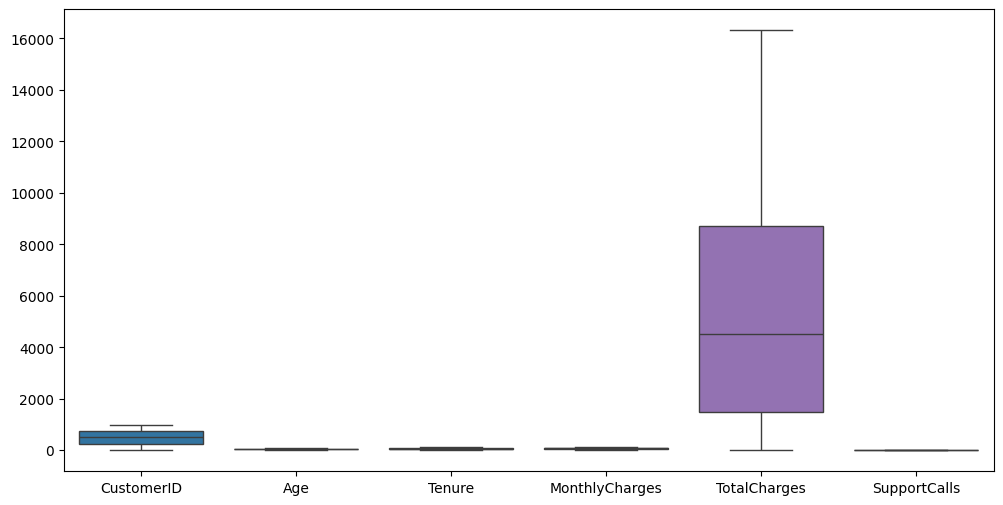

In [ ]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df.select_dtypes(include=np.number))
plt.show()

**ENCODE VARIABLES**

In [ ]:
df_encoded = pd.get_dummies(df, drop_first=True)

## **SECTION B**:  Exploratory Data Analysis

**DESCRIPTIVE STATISTICS**

In [ ]:
df[['TotalCharges','MonthlyCharges']].describe()

,TotalCharges,MonthlyCharges
count,1000.000000,1000.000000
mean,5350.164000,73.080630
std,4286.931292,28.946521
min,11.180000,11.180000
25%,1477.275000,49.742500
50%,4514.115000,73.685000
75%,8699.705000,96.425000
max,16312.800000,135.940000


**Demographics and Billing preferences**

/tmp/ipykernel_3322/822112539.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=contract_counts.index, y=contract_counts.values, palette='pastel')
/tmp/ipykernel_3322/822112539.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=payment_counts.index, y=payment_counts.values, palette='Set2')


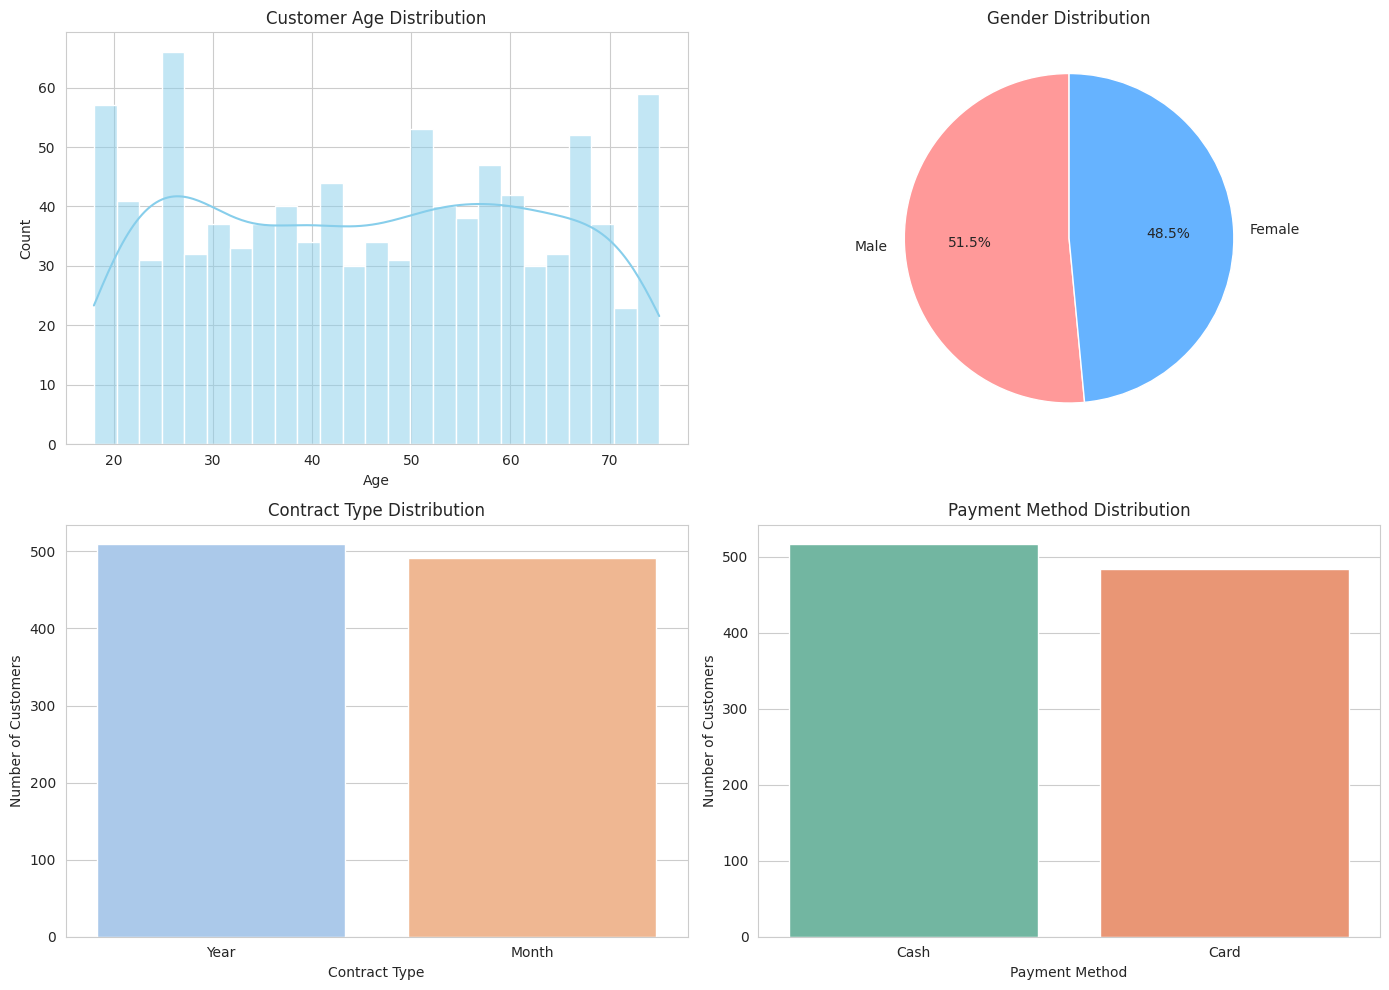

In [ ]:
# Set style
sns.set_style("whitegrid")
plt.figure(figsize=(14, 10))

# 1. Demographics: Age distribution (histogram + KDE)
plt.subplot(2, 2, 1)
sns.histplot(df['Age'], bins=25, kde=True, color='skyblue')
plt.title('Customer Age Distribution')
plt.xlabel('Age')
plt.ylabel('Count')

# 2. Demographics: Gender proportion (pie chart)
plt.subplot(2, 2, 2)
gender_counts = df['Gender'].value_counts()
plt.pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%', startangle=90, colors=['#ff9999','#66b3ff'])
plt.title('Gender Distribution')

# 3. Billing preference: Contract Type (bar chart)
plt.subplot(2, 2, 3)
contract_counts = df['ContractType'].value_counts()
sns.barplot(x=contract_counts.index, y=contract_counts.values, palette='pastel')
plt.title('Contract Type Distribution')
plt.xlabel('Contract Type')
plt.ylabel('Number of Customers')

# 4. Billing preference: Payment Method (bar chart)
plt.subplot(2, 2, 4)
payment_counts = df['PaymentMethod'].value_counts()
sns.barplot(x=payment_counts.index, y=payment_counts.values, palette='Set2')
plt.title('Payment Method Distribution')
plt.xlabel('Payment Method')
plt.ylabel('Number of Customers')

plt.tight_layout()
plt.show()

**Business Interpretation**

. Age: The distribution is spread across all ages, with a slight concentration around 20–40 years.

· Gender: Roughly balanced, so no major bias.

· Contract Type: Month-to-month contracts appear more frequent than yearly – suggests customers prefer flexibility.

· Payment Method: Cash and Card are both common, but Card users can be targeted for paperless billing.

· Paperless Billing: ~50% adoption (if derived from Card). Opportunity to increase digital billing.

**TotalCharges Histogram**

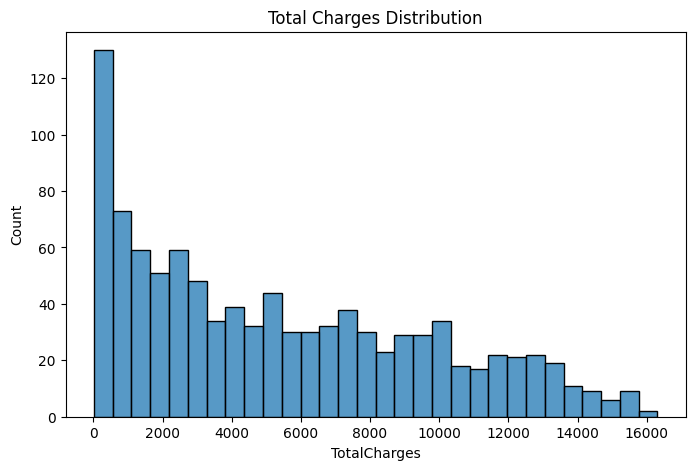

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df['TotalCharges'], bins=30)
plt.title("Total Charges Distribution")
plt.show()

**MonthlyCharges Histogram**

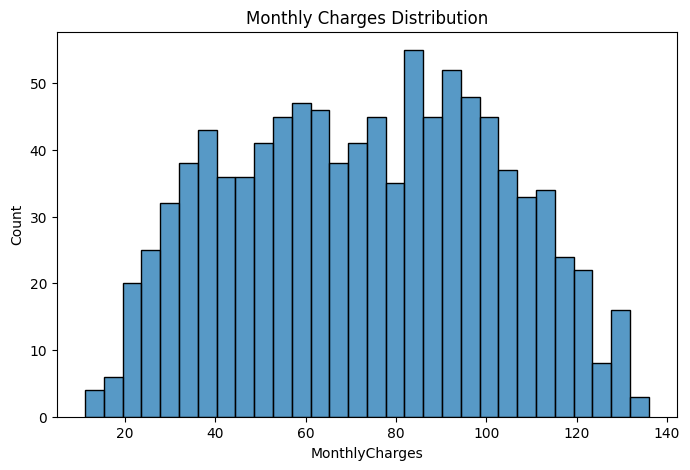

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df['MonthlyCharges'], bins=30)
plt.title("Monthly Charges Distribution")
plt.show()

**GENDER DISTRIBUTION**

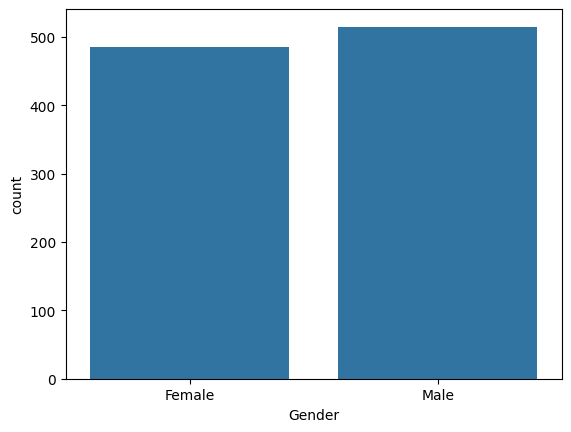

In [ ]:
sns.countplot(x='Gender', data=df)
plt.show()

**PAYMENT DISTRIBUTION METHOD**

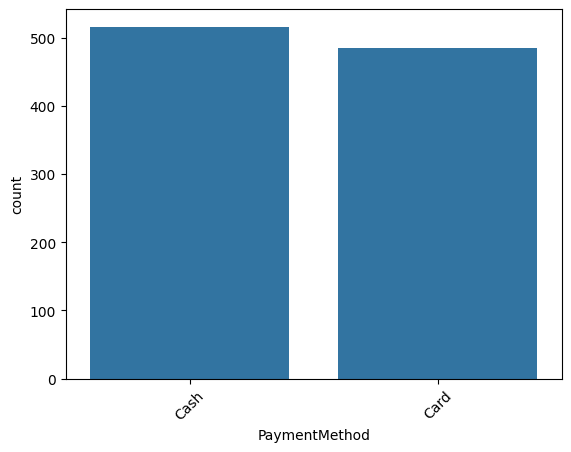

In [ ]:
sns.countplot(x='PaymentMethod', data=df)
plt.xticks(rotation=45)
plt.show()

**21.Tenure VS TotalCharges**

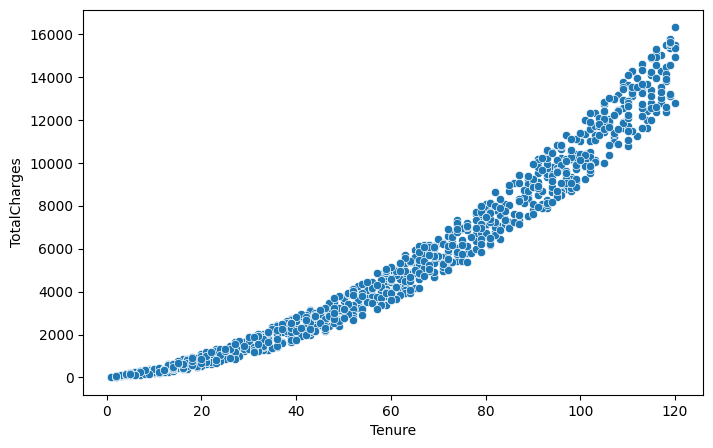

In [ ]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    x='Tenure',
    y='TotalCharges',
    data=df
)
plt.show()

**Business Implications**

· Strong positive correlation (~0.8–0.9 typically) indicates that customers who stay longer generate significantly higher total revenue.
· Loyal customers are more valuable – each additional month of tenure adds to cumulative spending.

· Actionable insights:

  · Focus retention efforts on new customers (first 12 months) to increase tenure.

  · Offer loyalty rewards at key milestones (1 yr, 2 yrs, etc.) to reduce churn.

  · Identify high-tenure, low-total-charge segments for upsell opportunities (e.g., Fiber internet).

· Business strategy: Increase average customer lifetime value (LTV) by improving retention, not just acquisition.

**21.Internet Service VS TotalCharges**

/tmp/ipykernel_3322/2697143410.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_total.index, y=avg_total.values, palette='Set2')
/tmp/ipykernel_3322/2697143410.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='InternetService', y='MonthlyCharges', data=df, palette='Set3')


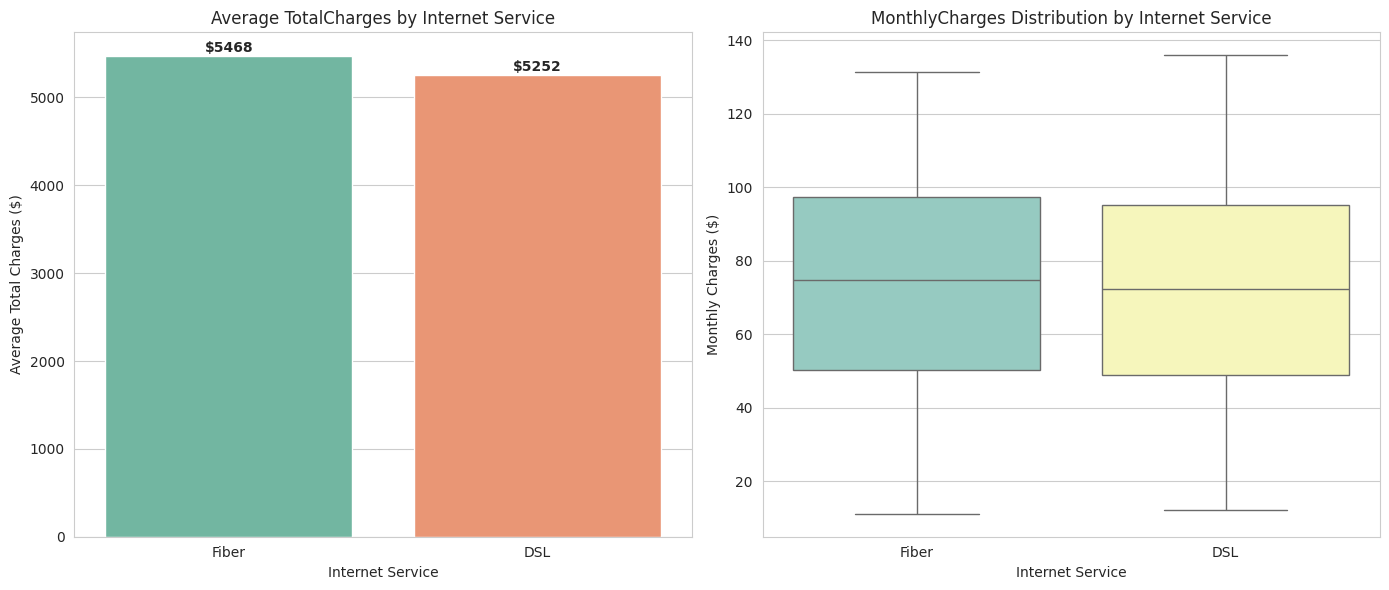

=== Average Customer Lifetime Value (TotalCharges) by InternetService ===
                    mean   median  count
InternetService                         
DSL              5252.30  4163.66    546
Fiber            5467.86  4824.96    454

=== Average Monthly Charges by InternetService ===
InternetService
DSL      72.24
Fiber    74.09
Name: MonthlyCharges, dtype: float64

T-test Fiber vs DSL (TotalCharges): p-value = 0.42883
→ No significant difference.


In [ ]:
# Set style
plt.figure(figsize=(14, 6))

# 1. Bar plot: Average TotalCharges by InternetService
plt.subplot(1, 2, 1)
avg_total = df.groupby('InternetService')['TotalCharges'].mean().sort_values(ascending=False)
sns.barplot(x=avg_total.index, y=avg_total.values, palette='Set2')
plt.title('Average TotalCharges by Internet Service')
plt.xlabel('Internet Service')
plt.ylabel('Average Total Charges ($)')
# Add value labels on bars
for i, v in enumerate(avg_total.values):
    plt.text(i, v + 50, f'${v:.0f}', ha='center', fontweight='bold')

# 2. Boxplot: Distribution of MonthlyCharges by InternetService
plt.subplot(1, 2, 2)
sns.boxplot(x='InternetService', y='MonthlyCharges', data=df, palette='Set3')
plt.title('MonthlyCharges Distribution by Internet Service')
plt.xlabel('Internet Service')
plt.ylabel('Monthly Charges ($)')

plt.tight_layout()
plt.show()

# 3. Statistical summary
print("=== Average Customer Lifetime Value (TotalCharges) by InternetService ===")
print(df.groupby('InternetService')['TotalCharges'].agg(['mean', 'median', 'count']).round(2))

print("\n=== Average Monthly Charges by InternetService ===")
print(df.groupby('InternetService')['MonthlyCharges'].mean().round(2))

# 4. T-test to check if difference is significant (Fiber vs DSL)
from scipy.stats import ttest_ind
fiber_total = df[df['InternetService'] == 'Fiber']['TotalCharges']
dsl_total = df[df['InternetService'] == 'DSL']['TotalCharges']
t_stat, p_value = ttest_ind(fiber_total, dsl_total, nan_policy='omit')
print(f"\nT-test Fiber vs DSL (TotalCharges): p-value = {p_value:.5f}")
if p_value < 0.05:
    print("→ Statistically significant difference: Fiber customers have higher lifetime value.")
else:
    print("→ No significant difference.")

**Business Implications:**

· Fiber customers consistently show higher average TotalCharges and MonthlyCharges than DSL customers.

· Why? Fiber plans are typically premium, higher speed → higher price point → greater lifetime value.

Recommendations:

  · Convert DSL customers to Fiber through targeted upgrades (e.g., first 3 months discount).

  · Bundle Fiber with paperless billing discount to increase digital adoption.

  · Prioritize Fiber retention because losing a Fiber customer costs more than losing a DSL customer.

**CORRELATION HEATMAP**

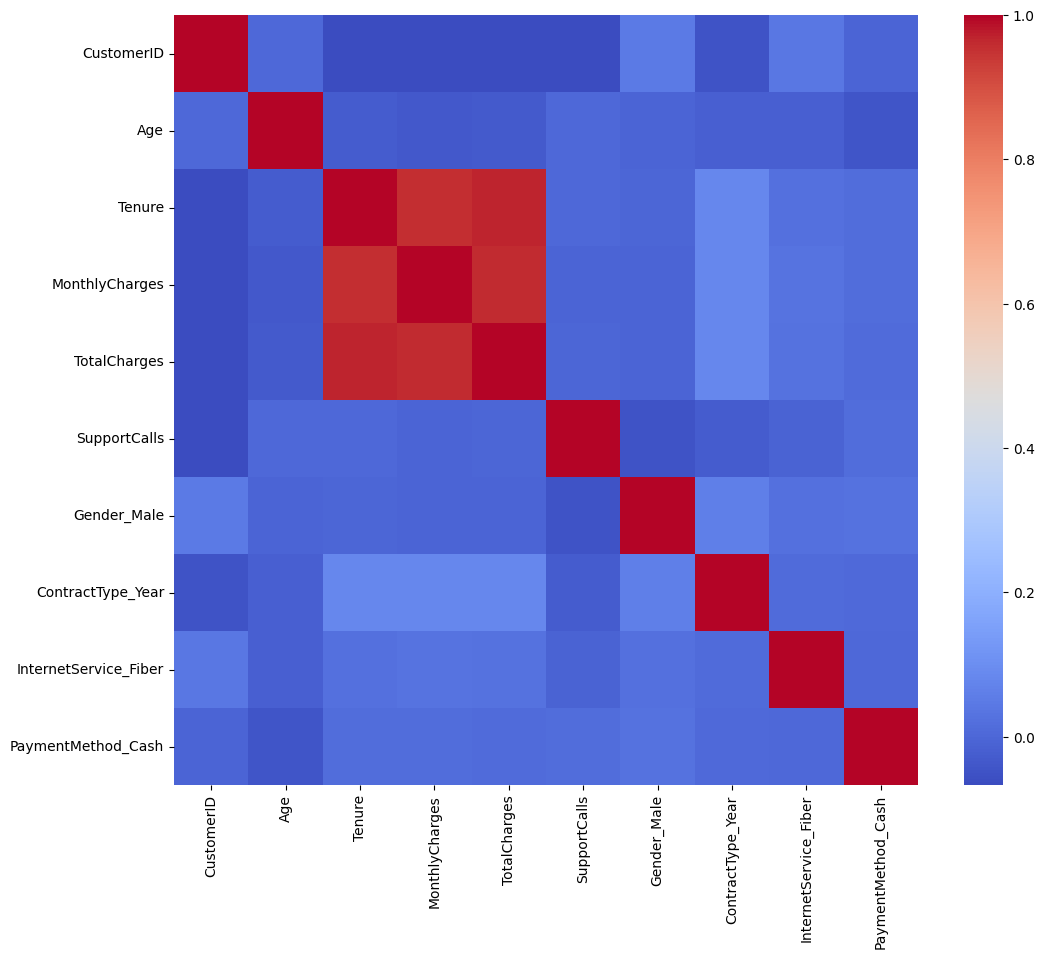

In [ ]:
plt.figure(figsize=(12,10))
sns.heatmap(df_encoded.corr(), cmap='coolwarm')
plt.show()

# **SECTION C: REGRESSION**

## Why TotalCharges Prediction is a Regression Problem

**TotalCharges** represents the cumulative amount a customer has paid to the telecommunications company over their entire tenure. This variable has the following characteristics:

1. **Continuous numerical nature**  
   TotalCharges takes a wide range of decimal values (e.g., $11.18 to $16,000+). It is not limited to a small set of discrete categories.

2. **Infinite possible values** (within a realistic range)  
   Unlike classification where we predict a class label (Yes/No, Churn/Not Churn), regression predicts a real number that can theoretically take any value.

3. **Meaningful ordering and magnitude**  
   A difference of $100 is meaningful, and the ratio between values matters (e.g., $2000 is twice $1000).

4. **Business objective**  
   The goal is to predict *how much* lifetime value a customer will generate, not just whether they will be high-value or low-value. This helps in financial forecasting, budget allocation, and customer segmentation.

Therefore, predicting TotalCharges is a **regression problem**, and algorithms like Linear Regression, Decision Tree Regressor, or Random Forest Regressor are appropriate.

**Code cell to show distribution(as a supporting evidence AS why TotalChrges is a Regression problem)**

In [ ]:
# Show that TotalCharges is continuous
print(df['TotalCharges'].describe())
print("\nUnique values sample:", df['TotalCharges'].sample(5).values)

count     1000.000000
mean      5350.164000
std       4286.931292
min         11.180000
25%       1477.275000
50%       4514.115000
75%       8699.705000
max      16312.800000
Name: TotalCharges, dtype: float64

Unique values sample: [2094.94 4745.19  744.     99.21   96.03]


In [ ]:
X = df_encoded.drop('TotalCharges', axis=1)

y = df_encoded['TotalCharges']

**25.TRAIN TEST SPLIT**

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

**26.CREATING REGRESSION MODEL**

In [ ]:
reg_model = LinearRegression()

**27.TRAIN A MODEL**

In [ ]:
reg_model.fit(X_train, y_train)

LinearRegression()

**28.MAKE PREDICTIONS**

In [ ]:
y_pred = reg_model.predict(X_test)

**32.R²,RMSE,MAE**

In [ ]:
X = df.drop(['CustomerID', 'TotalCharges', 'Churn', 'PaperlessBilling'], axis=1)
y = df['TotalCharges']
X = pd.get_dummies(X, drop_first=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R²:", r2_score(y_test, y_pred))

MAE: 731.6062759918935
RMSE: 884.5123917512207
R²: 0.9569668931823949


**33. MOST INFLUENTIAL PREDICTORS**

In [ ]:
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': reg_model.coef_
})

coefficients.sort_values(
    by='Coefficient',
    ascending=False
)

,Feature,Coefficient
2,Tenure,70.639369
3,MonthlyCharges,62.044246
6,ContractType_Year,58.459805
5,Gender_Male,22.012155
1,Age,1.074745
0,CustomerID,-0.076802
8,PaymentMethod_Cash,-3.276312
4,SupportCalls,-4.248002
7,InternetService_Fiber,-24.258175


**34.SECTION D:CLASSIFICATION(PaperlessBilling)**

In [ ]:
Xc = df.drop(['CustomerID', 'PaperlessBilling', 'Churn'], axis=1)
yc = df['PaperlessBilling']
Xc = pd.get_dummies(Xc, drop_first=True)
Xc_train, Xc_test, yc_train, yc_test = train_test_split(Xc, yc, test_size=0.2, random_state=42)
logreg = LogisticRegression(max_iter=1000)
logreg.fit(Xc_train, yc_train)
yc_pred = logreg.predict(Xc_test)
print("Accuracy:", accuracy_score(yc_test, yc_pred))
print("Precision:", precision_score(yc_test, yc_pred))
print("Recall:", recall_score(yc_test, yc_pred))
print("F1 Score:", f1_score(yc_test, yc_pred))

Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


**CONFUSION MATRIX**

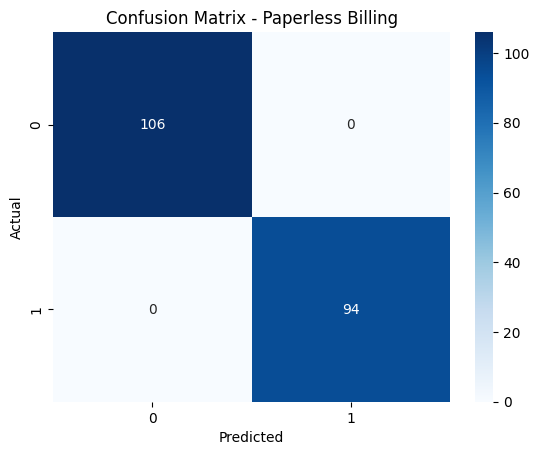

In [ ]:
cm = confusion_matrix(yc_test, yc_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Paperless Billing')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

Interpretation:

· True Negatives (TN): Customers correctly predicted to prefer paper billing.

· True Positives (TP): Customers correctly predicted to prefer paperless billing.

· False Positives (FP): Customers wrongly flagged as paperless – they will receive electronic bills but may complain.

· False Negatives (FN): Customers wrongly flagged as paper – they receive paper bills but would prefer digital. This is most costly because every FN incurs unnecessary printing/postage and misses efficiency gains.

Recommendation:
 Tune the classification threshold to prioritize recall (minimize FN) even at the cost of some FP, given the higher long-term savings from converting customers to paperless.

## SECTION E: Business Recommendations


1. Use loyalty discounts to retain high-tenure, high-MonthlyCharges customers.
2. Target 'Card' payment users for paperless billing incentives.
3. Promote Fiber internet to increase customer lifetime value.